# Regresiòn lineal

In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [209]:
df = pd.read_csv(r"C:\Users\kevin\OneDrive\Escritorio\VISUAL ARCHIVOS\car data.csv")
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


* Selling_Price
Precio al que el propietario quiere vender el coche.

* Present_Price
Precio actual del coche en el concesionario.

In [210]:
# Descripciòn del DataFrame
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB
None


In [211]:
# Columnas del DataFrame
print(df.keys())

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')


In [212]:
# Datos estadisticos de las columnas numéricas
print(df.describe())

              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [213]:
print(df.shape)

(301, 9)


In [214]:
print(df.drop_duplicates())

    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Seller_Type Transmission  Owner  
0        Dealer       Manual      0  
1        Dealer       Manual      0

In [215]:
# Elimina datos duplicados
df.drop_duplicates(inplace=True)
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [216]:
# espacios sobrantes en columnas
df.columns = df.columns.str.strip()

df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [217]:
# Contar valores nulos en cada columna
print(df.isna().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [218]:
# Elimina valores atipicos
def iqr_mask(serie, k=3.0):
    q1, q3 = serie.quantile([.25, .75])
    rango = q3 - q1
    return (serie >= q1 - k * rango) & (serie <= q3 + k * rango)

mask = (iqr_mask(df.Present_Price) &
        iqr_mask(df.Selling_Price) &
        iqr_mask(df.Kms_Driven))

df = df[mask].reset_index(drop=True)
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
284,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
285,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
286,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
287,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


# Analisis de variables

In [219]:
# correlaciòn de variables
# Filtra automáticamente las columnas numéricas para calcular la correlación
matriz_correlacion = df.corr(numeric_only=True)
print(matriz_correlacion)


                   Year  Selling_Price  Present_Price  Kms_Driven     Owner
Year           1.000000       0.275192      -0.069927   -0.630469 -0.190235
Selling_Price  0.275192       1.000000       0.843376    0.126181 -0.096204
Present_Price -0.069927       0.843376       1.000000    0.457328  0.038630
Kms_Driven    -0.630469       0.126181       0.457328    1.000000  0.165126
Owner         -0.190235      -0.096204       0.038630    0.165126  1.000000


considerando la variable Y como el objetivo "Present_Price" se puede identificar que la variable x con mayor correlaciòn es Selling_Price con 0.87

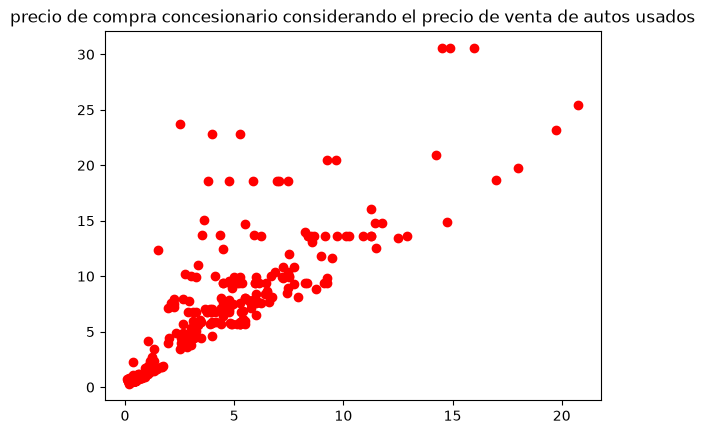

In [220]:
plt.plot(df["Selling_Price"], df["Present_Price"],"ro")
plt.title("precio de compra concesionario considerando el precio de venta de autos usados")
plt.show()

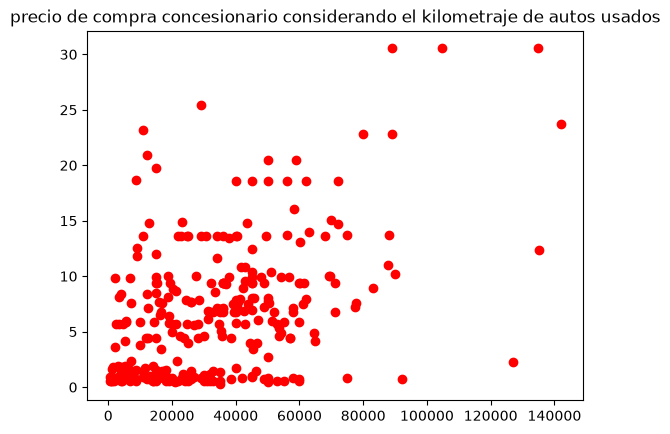

In [221]:
plt.plot(df["Kms_Driven"], df["Present_Price"],"ro")
plt.title("precio de compra concesionario considerando el kilometraje de autos usados")
plt.show()

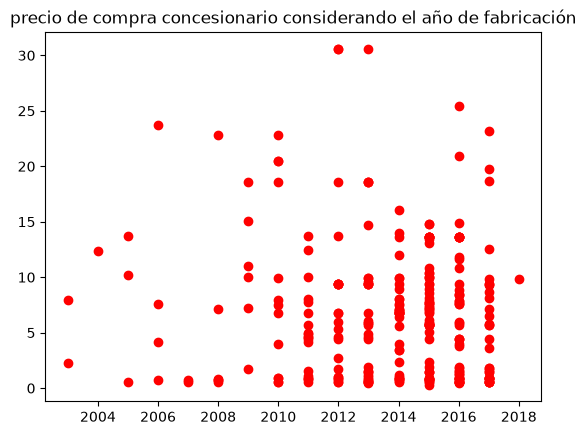

In [222]:
plt.plot(df["Year"], df["Present_Price"],"ro")
plt.title("precio de compra concesionario considerando el año de fabricación")
plt.show()

## Como se puede evidenciar las mejores variables para considerar X son precio de venta auto usado y kilometraje

In [223]:
X = df[["Selling_Price", "Kms_Driven"]]
Y = df["Present_Price"]

In [224]:
# Separa los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

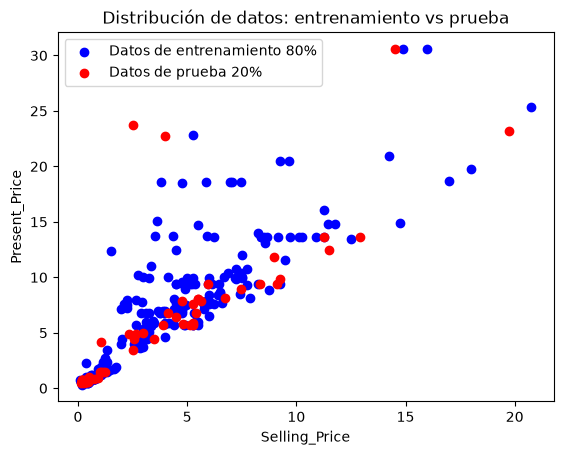

In [225]:
# Visualizaciòn
plt.scatter(X_train["Selling_Price"], Y_train, color='blue', label='Datos de entrenamiento 80%')
plt.scatter(X_test["Selling_Price"], Y_test, color='red', label='Datos de prueba 20%')
plt.legend()
plt.xlabel("Selling_Price")
plt.ylabel("Present_Price")
plt.title("Distribución de datos: entrenamiento vs prueba")
plt.show()

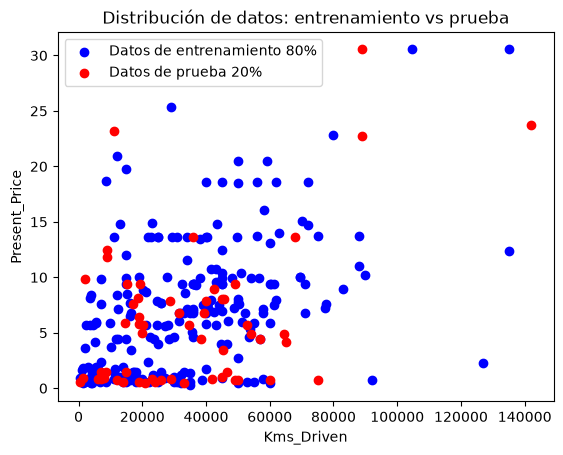

In [226]:
plt.scatter(X_train["Kms_Driven"], Y_train, color='blue', label='Datos de entrenamiento 80%')
plt.scatter(X_test["Kms_Driven"], Y_test, color='red', label='Datos de prueba 20%')
plt.legend()
plt.xlabel("Kms_Driven")
plt.ylabel("Present_Price")
plt.title("Distribución de datos: entrenamiento vs prueba")
plt.show()

In [227]:
#Implementación del modelo de regresión lineal y entrenamiento del modelo
modelo = LinearRegression()
modelo.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[1.27,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Selling_Price','Kms_Driven']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.066
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [228]:
# Se realiza la predción de los valores de prueba
y_pred = modelo.predict(X_test)

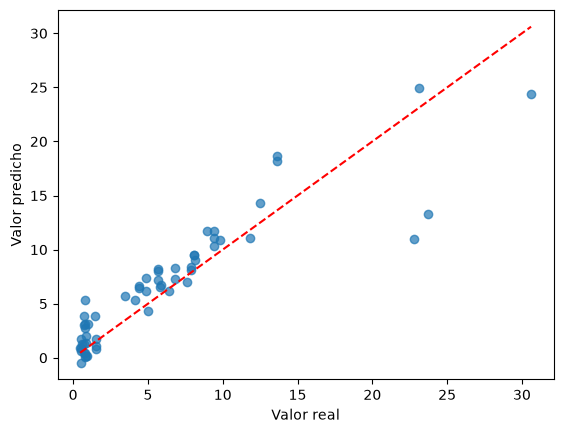

In [229]:
plt.scatter(Y_test, y_pred, alpha=0.7)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], "r--")
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")

plt.show()

In [230]:
# Calcular métricas de evaluación
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)
residuos = Y_test - y_pred_test
residuos.head()

45    -2.492184
157   -1.959136
274   -0.481906
42    -1.482660
181   -2.288531
Name: Present_Price, dtype: float64

residuos = y_test - y_pred_test 
el residuo es la diferencia entre lo real y lo predicho para cada carro. Es el "error" que comete el modelo en cada caso individual. Todo el análisis de supuestos se hace sobre este vector.

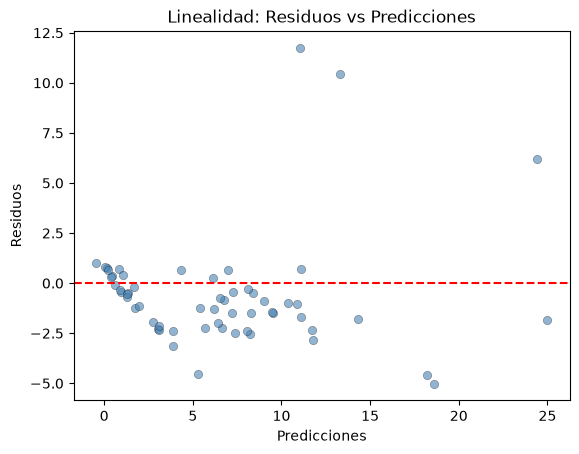

In [231]:
# --- Supuesto 1: Linealidad ---
# Si el modelo es adecuado, los residuos deben repartirse al azar
# alrededor de 0, sin formar ningún patrón (curva, embudo, etc.)

plt.scatter(y_pred_test, residuos, alpha=0.6, color='steelblue', edgecolor='k', linewidth=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Linealidad: Residuos vs Predicciones")
plt.show()

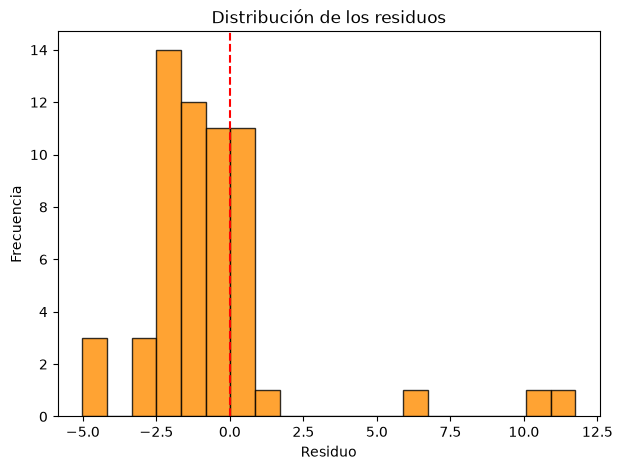

In [232]:
# Normalidad de los residuos 

plt.figure(figsize=(7,5))
plt.hist(residuos, bins=20, color='darkorange', edgecolor='black', alpha=0.8)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos")
plt.show()



## Evaluaciòn

In [233]:
# Calcular métricas de evaluación
mae  = mean_absolute_error(Y_test, y_pred)
mse  = mean_squared_error(Y_test, y_pred)
rmse = mse ** 0.5
r2   = r2_score(Y_test, y_pred)

print(f"MAE: {mae:.3f} | MSE: {mse:.3f} | RMSE: {rmse:.3f} | R2: {r2:.3f}")
print(f"Ecuación: Y = {modelo.intercept_:.3f} + {modelo.coef_[0]:.3f}*Selling + {modelo.coef_[1]:.8f}*Kms")



MAE: 1.857 | MSE: 8.071 | RMSE: 2.841 | R2: 0.807
Ecuación: Y = -1.066 + 1.275*Selling + 0.00007855*Kms


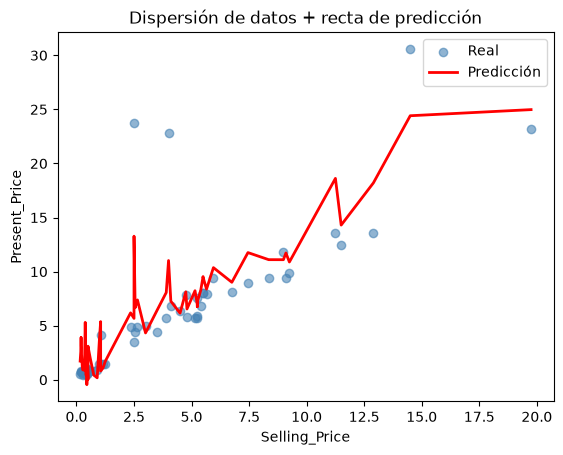

In [234]:

plt.scatter(X_test["Selling_Price"], Y_test, alpha=0.6, color='steelblue', label='Real')

orden = X_test["Selling_Price"].argsort()
plt.plot(X_test["Selling_Price"].values[orden], y_pred_test[orden], color='red', linewidth=2, label='Predicción')
plt.xlabel("Selling_Price")
plt.ylabel("Present_Price")
plt.title("Dispersión de datos + recta de predicción")
plt.legend()
plt.show()

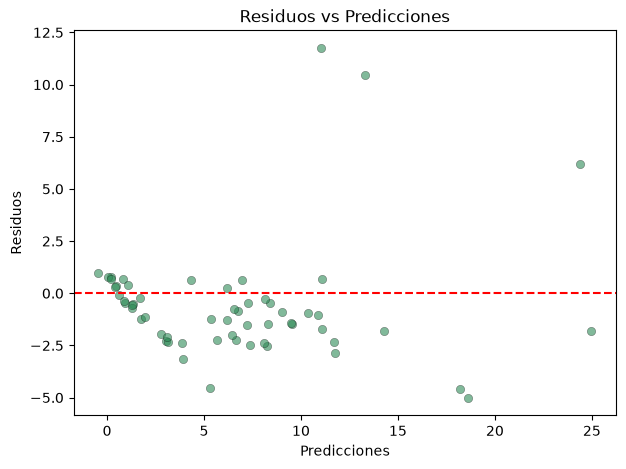

In [235]:
plt.figure(figsize=(7,5))
plt.scatter(y_pred_test, residuos, alpha=0.6, color='seagreen', edgecolor='k', linewidth=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos vs Predicciones")
plt.show()

## Analizar score

score_train — qué tan bien predice el modelo sobre los datos con los que aprendió (entrenamiento).
score_test — qué tan bien predice sobre datos que nunca vio durante el entrenamiento (prueba).

In [236]:
score_train = modelo.score(X_train, Y_train)
score_test = modelo.score(X_test, Y_test)

print(f"Score en entrenamiento: {score_train:.4f}")
print(f"Score en prueba:        {score_test:.4f}")

Score en entrenamiento: 0.8428
Score en prueba:        0.8069


## Conclusiòn

In [237]:
diferencia = score_train - score_test
print(f"Diferencia train - test:     {diferencia:.4f}")
if diferencia > 0.15:
    print("Alerta: posible sobreajuste (el modelo memorizó el train)")
elif score_test < 0.5:
    print("El modelo explica menos de la mitad de la varianza")
else:
    print("El modelo generaliza razonablemente bien")

Diferencia train - test:     0.0359
El modelo generaliza razonablemente bien
